In [ ]:
import pandas as pd
import numpy as np
import joblib
import zipfile
import glob

xgb= joblib.load('/content/XGB_Tuned_2021_2024.pkl')
le = joblib.load('/content/LabelEncoder_Tuned.pkl')
feature_cols = joblib.load('/content/Feature_List.pkl')

print(feature_cols)
print(xgb.feature_names_in_)

['NDVI', 'NDRE', 'VV', 'VH', 'RVI', 'VV_Lag1', 'VV_Lag2', 'VH_Lag1', 'VH_Lag2', 'RVI_Lag1', 'RVI_Lag2', 'Delta_VV', 'Delta_VH', 'Delta_RVI', 'Month', 'S2_Quality']
['NDVI' 'NDRE' 'VV' 'VH' 'RVI' 'VV_Lag1' 'VV_Lag2' 'VH_Lag1' 'VH_Lag2'
 'RVI_Lag1' 'RVI_Lag2' 'Delta_VV' 'Delta_VH' 'Delta_RVI' 'Month'
 'S2_Quality']


In [ ]:
list(feature_cols) == list(xgb.feature_names_in_)

True

In [ ]:
with zipfile.ZipFile('/content/Indramayu_Data_GRID.zip', 'r') as z:
    z.extractall('/content/grid')

files = sorted(glob.glob('/content/grid/*.csv'))

dfs = []
for f in files:
    tmp = pd.read_csv(f)
    dfs.append(tmp)

df = pd.concat(dfs, ignore_index=True)

print(df.shape)

(452863, 18)


In [ ]:
sensor_cols = [
    'NDVI',
    'NDRE',
    'VV',
    'VH',
    'RVI'
]

df[sensor_cols] = (
    df[sensor_cols]
    .replace([-9999, -999], np.nan)
)

In [ ]:
df['Year'] = 2025

In [ ]:
df['S2_missing'] = (
    df['NDVI'].isna() |
    df['NDRE'].isna()
)

quality = (
    df.groupby(['GRID_ID','Year'])['S2_missing']
      .mean()
      .reset_index()
)

quality.columns = [
    'GRID_ID',
    'Year',
    'Missing_S2'
]

def classify_quality(x):
    if x <= 0.30:
        return 2
    elif x <= 0.50:
        return 1
    else:
        return 0

quality['S2_Quality'] = (
    quality['Missing_S2']
    .apply(classify_quality)
)

df = df.merge(
    quality[['GRID_ID','Year','S2_Quality']],
    on=['GRID_ID','Year'],
    how='left'
)

In [ ]:
df['StartDate'] = pd.to_datetime(
    df['StartDate']
)

df['Month'] = (
    df['StartDate']
    .dt.month
)

In [ ]:
df = (
    df.sort_values(
        ['GRID_ID','Period']
    )
    .reset_index(drop=True)
)

In [ ]:
for col in [
    'VV',
    'VH',
    'RVI'
]:

    df[f'{col}_Lag1'] = (
        df.groupby('GRID_ID')[col]
          .shift(1)
    )

    df[f'{col}_Lag2'] = (
        df.groupby('GRID_ID')[col]
          .shift(2)
    )

    df[f'Delta_{col}'] = (
        df[col]
        -
        df[f'{col}_Lag1']
    )

In [ ]:
X = df[
    xgb.feature_names_in_
].copy()

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

In [ ]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', '_', '__', '___', '_i', '_ii', '_iii', '_i1', 'pd', 'np', 'joblib', 'zipfile', 'glob', 'xgb', 'le', 'feature_cols', '_i2', '_2', '_i3', 'z', 'files', 'dfs', 'f', 'tmp', 'df', '_i4', 'sensor_cols', '_i5', '_i6', 'quality', 'classify_quality', '_i7', '_i8', '_i9', 'col', '_i10', 'X', '_i11'])

In [ ]:
pred_num = xgb.predict(X)

df['Pred_xgb'] = le.inverse_transform(pred_num)

In [ ]:
df['Pred_xgb'].value_counts()

,count
Pred_xgb,
Bare,137703
Veg1,90725
Veg2,50361
Gen1,48735
EarlyVeg,46508
Gen2,42435
Flooding,36396


In [ ]:
import geopandas as gpd

In [ ]:
import zipfile

with zipfile.ZipFile('/content/aoi.zip', 'r') as z:
    z.extractall('/content/aoi')

kec = gpd.read_file('/content/aoi/aoi.shp')

In [ ]:
# =====================================================
# HITUNG SATU KALI PANEN PER GRID PER MUSIM TANAM
# =====================================================

df = df.sort_values(
    ["GRID_ID", "Period"]
).reset_index(drop=True)

# Event panen = awal masuk Gen2
df["Prev_Phase"] = (
    df.groupby("GRID_ID")["Pred_xgb"]
      .shift(1)
)

panen = df[
    (df["Pred_xgb"] == "Gen2") &
    (df["Prev_Phase"] != "Gen2")
].copy()

print("Jumlah event panen :", len(panen))
print("GRID unik :", panen["GRID_ID"].nunique())

Jumlah event panen : 31607
GRID unik : 18100


In [ ]:
gdf_panen = gpd.GeoDataFrame(
    panen,
    geometry=gpd.points_from_xy(
        panen["Longitude"],
        panen["Latitude"]
    ),
    crs="EPSG:4326"
)

In [ ]:
kec = kec.to_crs(gdf_panen.crs)

In [ ]:
panen_kec = gpd.sjoin(
    gdf_panen,
    kec[["WADMKC","geometry"]],
    how="left",
    predicate="within"
)

In [ ]:
panen_kec["Luas_Panen_ha"] = 6.25

luas_kec = (
    panen_kec
    .groupby("WADMKC")
    .agg(
        Jumlah_Panen=("GRID_ID","count"),
        Luas_Panen_ha=("Luas_Panen_ha","sum")
    )
    .reset_index()
)

In [ ]:
import pandas as pd

df_excel = pd.read_excel(
    "/content/DATA PADI DAN PALAWIJA PERBULAN TH. 2025 bulan Desember.xlsx",
    header=None
)

aktual = pd.DataFrame({
    "WADMKC": df_excel.iloc[4:35, 46].values,
    "Produksi_Aktual_ton": pd.to_numeric(
        df_excel.iloc[4:35, 61],
        errors="coerce"
    ),
    "Produktivitas_ku_ha": pd.to_numeric(
        df_excel.iloc[4:35, 83],
        errors="coerce"
    )
})

aktual["Produktivitas_ton_ha"] = (
    aktual["Produktivitas_ku_ha"] / 10
)

print(aktual.head())

       WADMKC  Produksi_Aktual_ton  Produktivitas_ku_ha  Produktivitas_ton_ha
4  Haurgeulis             63296.27            68.406214              6.840621
5      Gantar            154150.32            67.488429              6.748843
6       Kroya             88615.04            67.650233              6.765023
7  Gabuswetan             82260.11            65.619105              6.561910
8    Cikedung             90876.43            71.884536              7.188454


In [ ]:
hasil = luas_kec.merge(
    aktual,
    on="WADMKC",
    how="left"
)

In [ ]:
hasil["Produksi_Estimasi_ton"] = (
    hasil["Luas_Panen_ha"]
    *
    hasil["Produktivitas_ton_ha"]
)

In [ ]:
panen_kec['WADMKC'].value_counts()

,count
WADMKC,
Kroya,3546
Terisi,2886
Gantar,2763
Gabuswetan,2173
Anjatan,1645
Haurgeulis,1564
Cikedung,1460
Kandanghaur,1424
Lelea,1183


In [ ]:
panen_kec['Luas_Panen_ha'] = 6.25

luas_kec = (
    panen_kec
    .groupby('WADMKC')
    .agg(
        Jumlah_Panen=('GRID_ID', 'count'),
        Luas_Panen_ha=('Luas_Panen_ha', 'sum')
    )
    .reset_index()
)

luas_kec

,WADMKC,Jumlah_Panen,Luas_Panen_ha
0,Anjatan,1645,10281.25
1,Arahan,289,1806.25
2,Balongan,479,2993.75
3,Bangodua,656,4100.00
4,Bongas,937,5856.25
5,Cantigi,374,2337.50
6,Cikedung,1460,9125.00
7,Gabuswetan,2173,13581.25
8,Gantar,2763,17268.75
9,Haurgeulis,1564,9775.00


In [ ]:
panen_kec['Pred_xgb'].value_counts()

,count
Pred_xgb,
Gen2,31607


In [ ]:
df_excel = pd.read_excel(
    '/content/DATA PADI DAN PALAWIJA PERBULAN TH. 2025 bulan Desember.xlsx',
    header=None
)

df_excel.head(20)

,0,1,2,3,4,5,6,7,8,9,...,98,99,100,101,102,103,104,105,106,107
0,DATA LUAS TANAM PADI DI KABUPATEN INDRAMAYU TA...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,s/d November 2025,NaN,NaN,NaN,NaN,(Ha),NaN,NaN,NaN
2,No,Kecamatan,MT. 2024/2025,NaN,NaN,NaN,NaN,NaN,NaN,Jumlah,...,NaN,NaN,NaN,NaN,NaN,Jumlah,JUMLAH,NaN,NaN,NaN
3,NaN,NaN,NaN,nop,Des,jan,feb,mar,NaN,NaN,...,juli,agst,sept,okt,nov,NaN,TH. 2025,NaN,IRIGASI,TADAH HUJAN
4,1,Haurgeulis,0,0,1723,2683,0,0,0,4406,...,0,0,0,0,0,0,0,0.0,NaN,NaN
5,2,Gantar,0,,9929,890,84,0,0,11204,...,0,0,0,0,0,0,0,0.0,NaN,NaN
6,3,Kroya,0,0,3782,2705,0,0,0,6487,...,0,0,0,0,0,0,0,0.0,NaN,NaN
7,4,Gabuswetan,0,75,284,4431,1178,0,0,5968,...,0,0,0,0,0,0,0,0.0,NaN,NaN
8,5,Cikedung,0,0,1925,4876,868,0,0,7669,...,0,0,0,0,0,0,0,0.0,NaN,NaN
9,6,Terisi,0,436,2181,6446,507,0,0,9570,...,0,0,0,0,0,0,0,0.0,NaN,NaN


In [ ]:
aktual = pd.DataFrame({
    'WADMKC': df_excel.iloc[4:35, 46].values,
    'Produksi_Aktual_ton': pd.to_numeric(
        df_excel.iloc[4:35, 61],
        errors='coerce'
    ),
    'Produktivitas_ku_ha': pd.to_numeric(
        df_excel.iloc[4:35, 83],
        errors='coerce'
    )
})

aktual['Produktivitas_ton_ha'] = (
    aktual['Produktivitas_ku_ha'] / 10
)

aktual.head()

,WADMKC,Produksi_Aktual_ton,Produktivitas_ku_ha,Produktivitas_ton_ha
4,Haurgeulis,63296.27,68.406214,6.840621
5,Gantar,154150.32,67.488429,6.748843
6,Kroya,88615.04,67.650233,6.765023
7,Gabuswetan,82260.11,65.619105,6.561910
8,Cikedung,90876.43,71.884536,7.188454


In [ ]:
hasil = luas_kec.merge(
    aktual,
    on='WADMKC',
    how='left'
)

hasil.head()

,WADMKC,Jumlah_Panen,Luas_Panen_ha,Produksi_Aktual_ton,Produktivitas_ku_ha,Produktivitas_ton_ha
0,Anjatan,1645,10281.25,80861.36,65.794434,6.579443
1,Arahan,289,1806.25,24750.55,66.695096,6.669510
2,Balongan,479,2993.75,26022.39,67.033462,6.703346
3,Bangodua,656,4100.00,45856.29,71.227540,7.122754
4,Bongas,937,5856.25,40700.85,51.782252,5.178225


In [ ]:
hasil['Produksi_Estimasi_ton'] = (
    hasil['Luas_Panen_ha']
    *
    hasil['Produktivitas_ton_ha']
)

In [ ]:
hasil[
    [
        'WADMKC',
        'Luas_Panen_ha',
        'Produktivitas_ton_ha',
        'Produksi_Estimasi_ton',
        'Produksi_Aktual_ton'
    ]
]

,WADMKC,Luas_Panen_ha,Produktivitas_ton_ha,Produksi_Estimasi_ton,Produksi_Aktual_ton
0,Anjatan,10281.25,6.579443,67644.902970,80861.360
1,Arahan,1806.25,6.669510,12046.801654,24750.550
2,Balongan,2993.75,6.703346,20068.142726,26022.390
3,Bangodua,4100.00,7.122754,29203.291240,45856.290
4,Bongas,5856.25,5.178225,30324.981274,40700.850
5,Cantigi,2337.50,7.188033,16802.027384,27357.654
6,Cikedung,9125.00,7.188454,65594.638803,90876.430
7,Gabuswetan,13581.25,6.561910,89118.946948,82260.110
8,Gantar,17268.75,6.748843,116544.080316,154150.320
9,Haurgeulis,9775.00,6.840621,66867.074381,63296.270


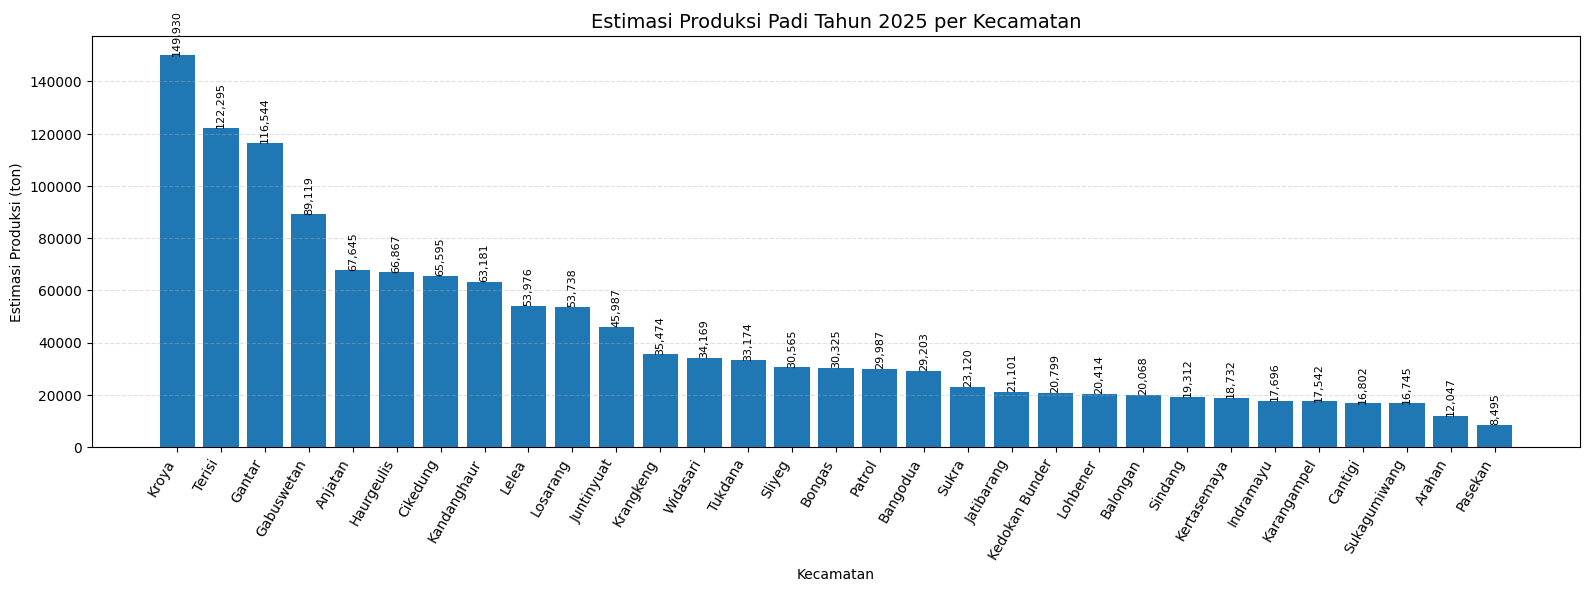

In [ ]:
import matplotlib.pyplot as plt

# ===============================
# Grafik Estimasi Produksi per Kecamatan
# ===============================

plot_df = hasil.copy()

# Urutkan dari terbesar ke terkecil (opsional)
plot_df = plot_df.sort_values(
    "Produksi_Estimasi_ton",
    ascending=False
)

plt.figure(figsize=(16,6))

bars = plt.bar(
    plot_df["WADMKC"],
    plot_df["Produksi_Estimasi_ton"]
)

# Menampilkan nilai di atas batang
for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f'{y:,.0f}',
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=90
    )

plt.title("Estimasi Produksi Padi Tahun 2025 per Kecamatan", fontsize=14)
plt.xlabel("Kecamatan")
plt.ylabel("Estimasi Produksi (ton)")

plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.savefig(
    "/content/Grafik_Estimasi_Produksi_Per_Kecamatan.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

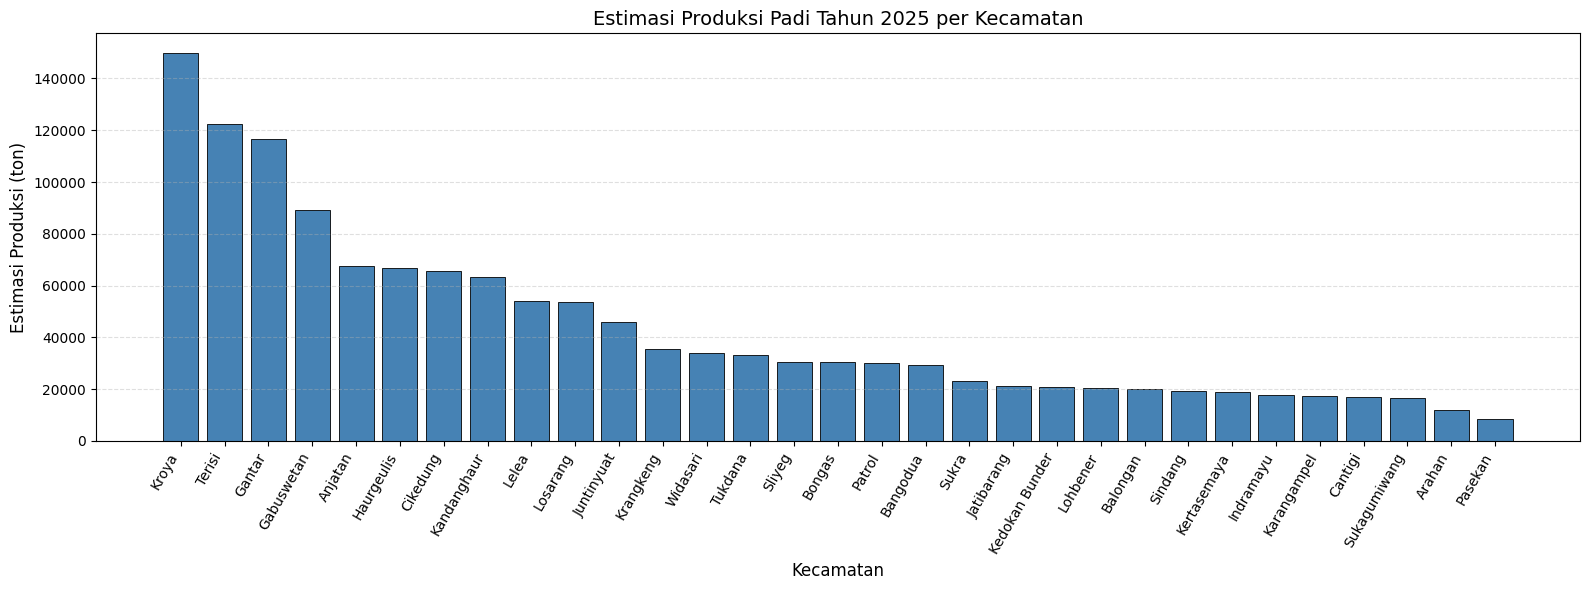

In [ ]:
import matplotlib.pyplot as plt

# ===============================
# Grafik Estimasi Produksi per Kecamatan
# ===============================

plot_df = hasil.copy()

# Urutkan berdasarkan estimasi produksi (opsional)
plot_df = plot_df.sort_values(
    "Produksi_Estimasi_ton",
    ascending=False
)

plt.figure(figsize=(16,6))

plt.bar(
    plot_df["WADMKC"],
    plot_df["Produksi_Estimasi_ton"],
    color="steelblue",
    edgecolor="black",
    linewidth=0.6
)

plt.title("Estimasi Produksi Padi Tahun 2025 per Kecamatan", fontsize=14)
plt.xlabel("Kecamatan", fontsize=12)
plt.ylabel("Estimasi Produksi (ton)", fontsize=12)

plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.savefig(
    "/content/Grafik_Estimasi_Produksi_Per_Kecamatan.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

valid = hasil.dropna(
    subset=[
        'Produksi_Estimasi_ton',
        'Produksi_Aktual_ton'
    ]
)

mae = mean_absolute_error(
    valid['Produksi_Aktual_ton'],
    valid['Produksi_Estimasi_ton']
)

rmse = np.sqrt(
    mean_squared_error(
        valid['Produksi_Aktual_ton'],
        valid['Produksi_Estimasi_ton']
    )
)

r2 = r2_score(
    valid['Produksi_Aktual_ton'],
    valid['Produksi_Estimasi_ton']
)

mape = (
    np.abs(
        valid['Produksi_Aktual_ton']
        -
        valid['Produksi_Estimasi_ton']
    )
    /
    valid['Produksi_Aktual_ton']
).mean() * 100

print(f"MAE  : {mae:,.2f} ton")
print(f"RMSE : {rmse:,.2f} ton")
print(f"R²   : {r2:.3f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 16,941.68 ton
RMSE : 20,370.36 ton
R²   : 0.583
MAPE : 33.20%


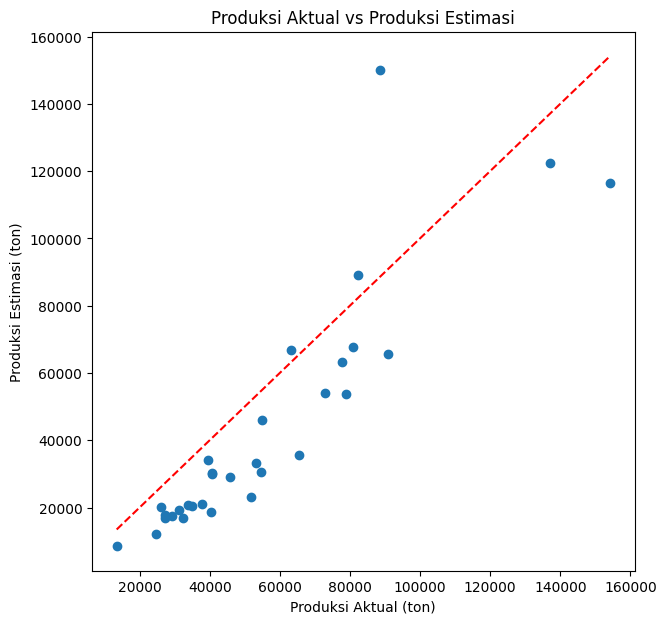

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(
    valid['Produksi_Aktual_ton'],
    valid['Produksi_Estimasi_ton']
)

xmin = valid['Produksi_Aktual_ton'].min()
xmax = valid['Produksi_Aktual_ton'].max()

plt.plot(
    [xmin, xmax],
    [xmin, xmax],
    'r--'
)

plt.xlabel('Produksi Aktual (ton)')
plt.ylabel('Produksi Estimasi (ton)')
plt.title('Produksi Aktual vs Produksi Estimasi')

plt.show()

In [ ]:
aktual_total = hasil['Produksi_Aktual_ton'].sum()
estimasi_total = hasil['Produksi_Estimasi_ton'].sum()

selisih = estimasi_total - aktual_total

persen = (
    selisih / aktual_total
) * 100

print('Aktual :', aktual_total)
print('Estimasi :', estimasi_total)
print('Selisih :', selisih)
print('Persen :', persen)

Aktual : 1732351.0399999998
Estimasi : 1350647.8262129042
Selisih : -381703.2137870956
Persen : -22.033825995630522


In [ ]:
hasil['Selisih_ton'] = (
    hasil['Produksi_Estimasi_ton']
    -
    hasil['Produksi_Aktual_ton']
)

hasil['APE_%'] = (
    abs(hasil['Selisih_ton'])
    /
    hasil['Produksi_Aktual_ton']
) * 100

hasil = hasil.sort_values(
    'APE_%',
    ascending=False
)

hasil[
    [
        'WADMKC',
        'Produksi_Aktual_ton',
        'Produksi_Estimasi_ton',
        'APE_%'
    ]
]

,WADMKC,Produksi_Aktual_ton,Produksi_Estimasi_ton,APE_%
18,Kroya,88615.040,149929.828537,69.192305
27,Sukra,51698.642,23119.947847,55.279390
16,Kertasemaya,40334.600,18731.780382,53.559028
1,Arahan,24750.550,12046.801654,51.327136
26,Sukagumiwang,32497.460,16744.736241,48.473708
17,Krangkeng,65485.220,35474.352800,45.828459
11,Jatibarang,37924.160,21100.708166,44.360776
25,Sliyeg,54596.110,30565.296967,44.015614
20,Lohbener,35069.540,20414.254289,41.789216
14,Karangampel,29124.220,17541.587527,39.769760


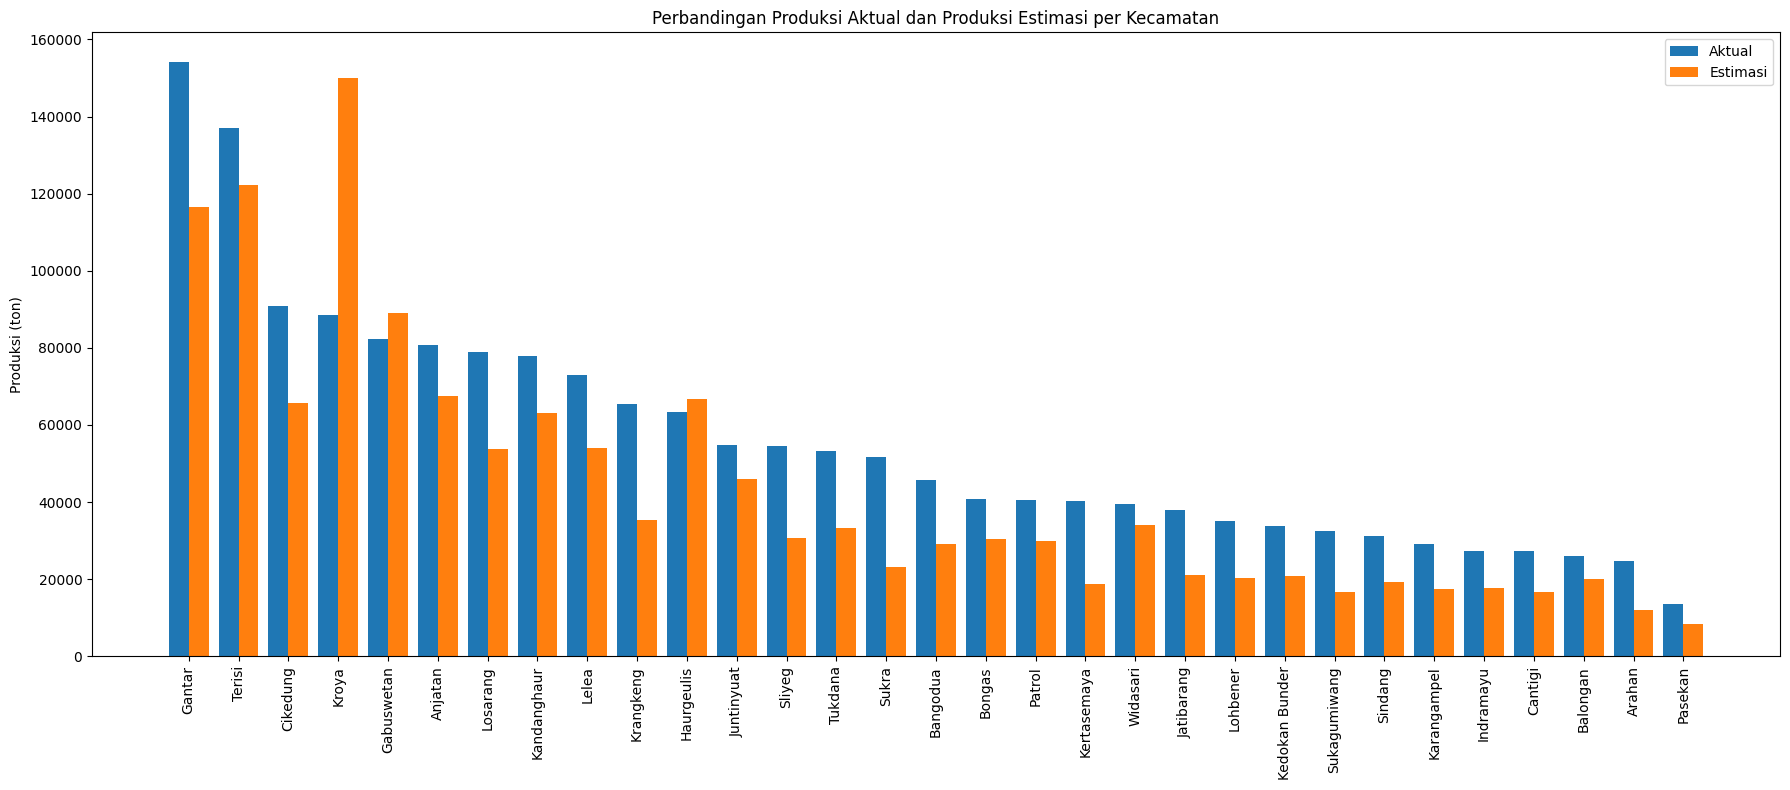

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = hasil.sort_values(
    'Produksi_Aktual_ton',
    ascending=False
)

x = np.arange(len(plot_df))
width = 0.4

fig, ax = plt.subplots(figsize=(18,8))

ax.bar(
    x - width/2,
    plot_df['Produksi_Aktual_ton'],
    width,
    label='Aktual'
)

ax.bar(
    x + width/2,
    plot_df['Produksi_Estimasi_ton'],
    width,
    label='Estimasi'
)

ax.set_xticks(x)
ax.set_xticklabels(
    plot_df['WADMKC'],
    rotation=90
)

ax.set_ylabel('Produksi (ton)')
ax.set_title(
    'Perbandingan Produksi Aktual dan Produksi Estimasi per Kecamatan'
)

ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
tabel = hasil[
    [
        'WADMKC',
        'Luas_Panen_ha',
        'Produksi_Aktual_ton',
        'Produksi_Estimasi_ton',
        'APE_%'
    ]
].copy()

tabel = tabel.sort_values(
    'Produksi_Aktual_ton',
    ascending=False
)

tabel = tabel.round({
    'Luas_Panen_ha':2,
    'Produksi_Aktual_ton':2,
    'Produksi_Estimasi_ton':2,
    'APE_%':2
})

tabel

,WADMKC,Luas_Panen_ha,Produksi_Aktual_ton,Produksi_Estimasi_ton,APE_%
8,Gantar,17268.75,154150.32,116544.08,24.40
28,Terisi,18037.50,137018.19,122295.29,10.75
6,Cikedung,9125.00,90876.43,65594.64,27.82
18,Kroya,22162.50,88615.04,149929.83,69.19
7,Gabuswetan,13581.25,82260.11,89118.95,8.34
0,Anjatan,10281.25,80861.36,67644.90,16.34
21,Losarang,6962.50,78919.18,53738.37,31.91
13,Kandanghaur,8900.00,77861.58,63180.90,18.85
19,Lelea,7393.75,72972.58,53975.69,26.03
17,Krangkeng,5093.75,65485.22,35474.35,45.83


In [ ]:
tabel.to_excel(
    '/content/Perbandingan_Produksi_Aktual_vs_Estimasi.xlsx',
    index=False
)

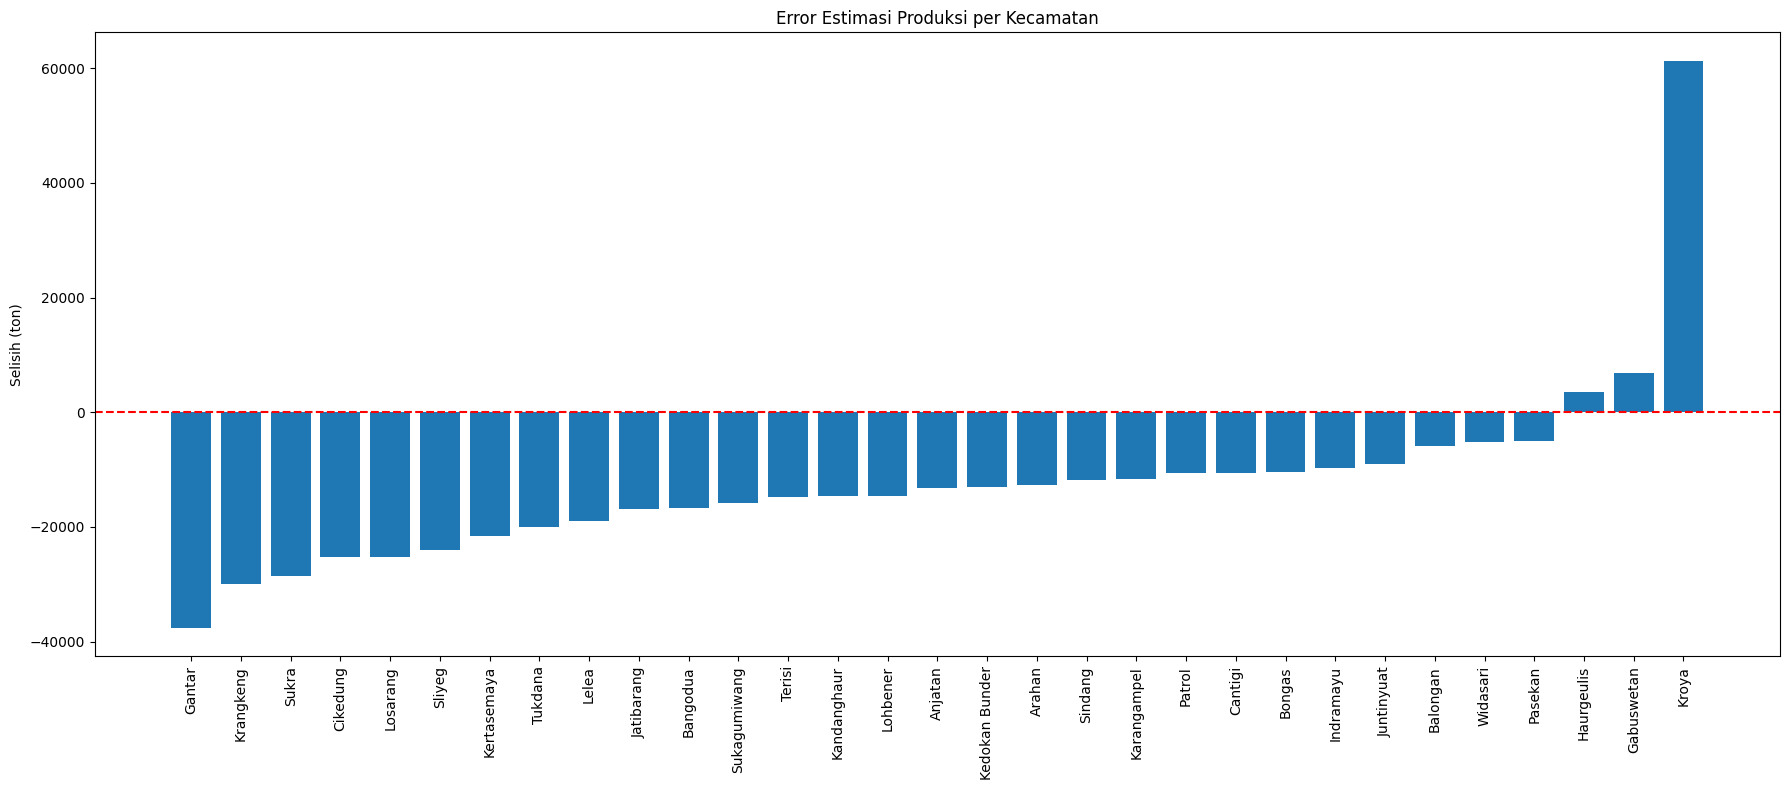

In [ ]:
hasil['Selisih_ton'] = (
    hasil['Produksi_Estimasi_ton']
    -
    hasil['Produksi_Aktual_ton']
)

plot_df = hasil.sort_values('Selisih_ton')

fig, ax = plt.subplots(figsize=(18,8))

ax.bar(
    plot_df['WADMKC'],
    plot_df['Selisih_ton']
)

ax.axhline(
    0,
    color='red',
    linestyle='--'
)

plt.xticks(rotation=90)
plt.ylabel('Selisih (ton)')
plt.title(
    'Error Estimasi Produksi per Kecamatan'
)

plt.tight_layout()
plt.show()

In [ ]:
output = hasil[
    [
        'WADMKC',
        'Luas_Panen_ha',
        'Produksi_Estimasi_ton',
        'Produksi_Aktual_ton',
        'Selisih_ton',
        'APE_%'
    ]
].copy()

output = output.round({
    'Luas_Panen_ha':2,
    'Produksi_Estimasi_ton':2,
    'Produksi_Aktual_ton':2,
    'Selisih_ton':2,
    'APE_%':2
})

output.to_csv(
    '/content/Validasi_Produksi_Padi_2025.csv',
    index=False,
    encoding='utf-8-sig'
)

print("Berhasil disimpan!")

Berhasil disimpan!


In [ ]:
from google.colab import files

# Data per grid yang diprediksi panen
panen_kec.to_csv("/content/panen_kec.csv", index=False, encoding="utf-8-sig")

# Rekap per kecamatan
luas_kec.to_csv("/content/luas_kec.csv", index=False, encoding="utf-8-sig")

# Hasil validasi akhir
output.to_csv("/content/Validasi_Produksi_Padi_2025.csv", index=False, encoding="utf-8-sig")

files.download("/content/panen_kec.csv")
files.download("/content/luas_kec.csv")
files.download("/content/Validasi_Produksi_Padi_2025.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>